In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

In [2]:
from linear_svm import LinearSVMScartch

In [3]:
from preprocessing import load_data
import joblib

X_train_s, X_val_s, X_test_s, y_train, y_val, y_test, X_dev, y_dev, scaler = load_data()

Loading MNIST (this may take a minute the first time)...
Total samples: 70000
Class +1 (is 6):      6876  (9.8%)
Class -1 (not 6):    63124  (90.2%)
Train: 42000, Val: 14000, Test: 14000
Dev set: 10000 samples (970 sixes, 9030 non-sixes)


In [4]:
results = []

for C in [0.01, 0.1, 1.0, 10.0]:
    for lr in [0.0001, 0.0005, 0.001]:
        svm = LinearSVMScartch(C=C, learning_rate=lr, n_epochs=50,
                               batch_size=64, use_class_weights=True,
                               random_state=42)
        svm.fit(X_dev, y_dev)
        val_f1 = f1_score(y_val, svm.predict(X_val_s))
        results.append((C, lr, val_f1))
        print(f"C={C}, lr={lr} → val F1={val_f1:.4f}")

best = max(results, key=lambda x: x[2])
best_C, best_lr = best[0], best[1]
print(f"\nBest: C={best_C}, lr={best_lr}, F1={best[2]:.4f}")

C=0.01, lr=0.0001 → val F1=0.5371
C=0.01, lr=0.0005 → val F1=0.7852
C=0.01, lr=0.001 → val F1=0.8354
C=0.1, lr=0.0001 → val F1=0.8214
C=0.1, lr=0.0005 → val F1=0.8631
C=0.1, lr=0.001 → val F1=0.8685
C=1.0, lr=0.0001 → val F1=0.8647
C=1.0, lr=0.0005 → val F1=0.8704
C=1.0, lr=0.001 → val F1=0.8501
C=10.0, lr=0.0001 → val F1=0.8595
C=10.0, lr=0.0005 → val F1=0.8379
C=10.0, lr=0.001 → val F1=0.8137

Best: C=1.0, lr=0.0005, F1=0.8704


In [5]:
print("Training final model on full training set...")
svm = LinearSVMScartch(
    C=best_C,
    learning_rate=best_lr,
    n_epochs=50,
    batch_size=64,
    use_class_weights=True,
    random_state=42,
)
svm.fit(X_train_s, y_train)
print("Done.")

Training final model on full training set...
Done.


In [6]:
y_pred = svm.predict(X_test_s)

print("=== TEST SET RESULTS ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['not 6', '6']))

=== TEST SET RESULTS ===
Accuracy : 0.9720
Precision: 0.7889
Recall   : 0.9760
F1 Score : 0.8726

Classification report:
              precision    recall  f1-score   support

       not 6       1.00      0.97      0.98     12625
           6       0.79      0.98      0.87      1375

    accuracy                           0.97     14000
   macro avg       0.89      0.97      0.93     14000
weighted avg       0.98      0.97      0.97     14000



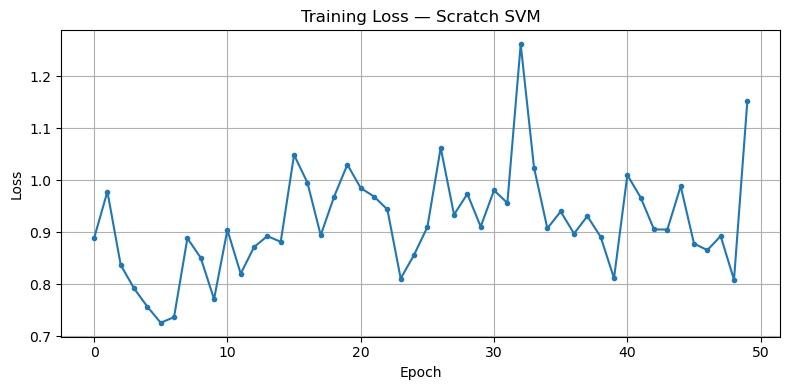

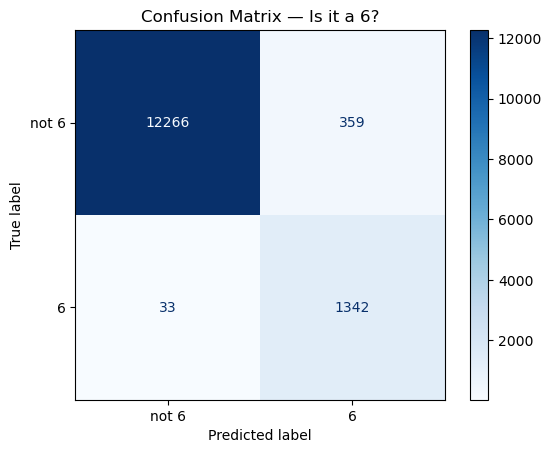

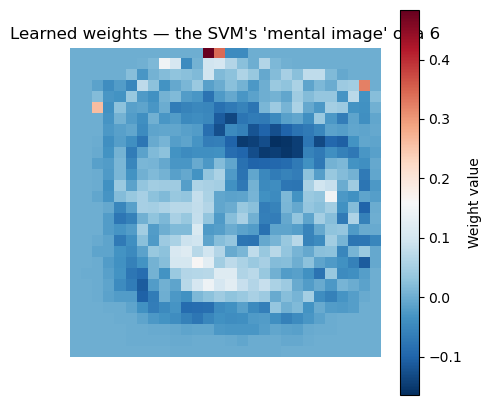

In [7]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(svm.history, marker='o', markersize=3)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training Loss — Scratch SVM")
plt.grid(True); plt.tight_layout(); plt.show()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[-1, 1])
ConfusionMatrixDisplay(cm, display_labels=['not 6', '6']).plot(cmap='Blues')
plt.title("Confusion Matrix — Is it a 6?"); plt.show()

# Learned weights visualized as 28x28 image
w_image = svm.w.reshape(28, 28)
plt.figure(figsize=(5, 5))
plt.imshow(w_image, cmap='RdBu_r')
plt.colorbar(label='Weight value')
plt.title("Learned weights — the SVM's 'mental image' of a 6")
plt.axis('off'); plt.show()

In [8]:
joblib.dump(svm, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and scaler saved.")

Model and scaler saved.


In [ ]:
from sklearn.svm import LinearSVC

sk_svm = LinearSVC(C=best_C, class_weight='balanced',
                   max_iter=5000, random_state=42)
sk_svm.fit(X_dev, y_dev)
sk_pred = sk_svm.predict(X_test_s)

print("=== Sanity check ===")
print(f"Scratch SVM test F1: {f1_score(y_test, y_pred):.4f}")
print(f"Sklearn  SVM test F1: {f1_score(y_test, sk_pred):.4f}")